In [2]:
import pandas as pd
import numpy as np
import random

In [3]:
ef = pd.read_csv('emission.csv', on_bad_lines='skip')
print(ef.head(21))

                  Activity                 Sub_Type  \
0          Video Streaming                       4K   
1          Video Streaming                    1080p   
2          Video Streaming                     720p   
3          Video Streaming                SD/Mobile   
4         Short-form Video  Autoplay (Reels/Shorts)   
5   Social Media Scrolling   Text-heavy (Twitter/X)   
6              Video Calls               Camera Off   
7                    Email               Plain Text   
8                    Email   With Attachment (>1MB)   
9            Cloud Storage                   Upload   
10           Cloud Storage                 Download   
11         Music Streaming   Normal (Spotify/Gaana)   
12           AI Tool Usage    LLM Query (GPT-scale)   
13           Online Gaming           Mobile (Local)   

    Emission_Factor_Global_kgCO2  India_Adjusted_Factor_kgCO2         Unit  \
0                        0.10000                      0.16700     kgCO2/hr   
1                 

In [4]:
ef_netflix_4k    = float(ef[ef['Sub_Type'] == '4K']['India_Adjusted_Factor_kgCO2'].values[0])
ef_netflix_1080p = float(ef[ef['Sub_Type'] == '1080p']['India_Adjusted_Factor_kgCO2'].values[0])
ef_netflix_720p  = float(ef[ef['Sub_Type'] == '720p']['India_Adjusted_Factor_kgCO2'].values[0])
ef_netflix_sd    = float(ef[ef['Sub_Type'] == 'SD/Mobile']['India_Adjusted_Factor_kgCO2'].values[0])
ef_instagram     = float(ef[ef['Sub_Type'] == 'Autoplay (Reels/Shorts)']['India_Adjusted_Factor_kgCO2'].values[0])
ef_call_on       = ef_netflix_720p # Proxy for video calls with camera on
ef_call_off      = float(ef[ef['Sub_Type'] == 'Camera Off']['India_Adjusted_Factor_kgCO2'].values[0])
ef_email_plain   = float(ef[ef['Sub_Type'] == 'Plain Text']['India_Adjusted_Factor_kgCO2'].values[0])
ef_email_attach  = float(ef[ef['Sub_Type'] == 'With Attachment (>1MB)']['India_Adjusted_Factor_kgCO2'].values[0])
ef_cloud_upload  = float(ef[ef['Sub_Type'] == 'Upload']['India_Adjusted_Factor_kgCO2'].values[0])
ef_music         = float(ef[ef['Sub_Type'] == 'Normal (Spotify/Gaana)']['India_Adjusted_Factor_kgCO2'].values[0])
ef_ai_query      = float(ef[ef['Sub_Type'] == 'LLM Query (GPT-scale)']['India_Adjusted_Factor_kgCO2'].values[0])
ef_gaming_cloud  = ef_netflix_1080p # Proxy for cloud gaming
ef_gaming_mobile = float(ef[ef['Sub_Type'] == 'Mobile (Local)']['India_Adjusted_Factor_kgCO2'].values[0])

print("Emission factors loaded successfully")
print(f"Netflix 4K: {ef_netflix_4k} kgCO2/hr")
print(f"Instagram (Reels/Shorts): {ef_instagram} kgCO2/hr")
print(f"Video call camera on (proxy): {ef_call_on} kgCO2/hr")
print(f"Video call camera off: {ef_call_off} kgCO2/hr")
print(f"AI query: {ef_ai_query} kgCO2/query")
print(f"Cloud Gaming (proxy): {ef_gaming_cloud} kgCO2/hr")
print(f"Mobile Gaming: {ef_gaming_mobile} kgCO2/hr")

Emission factors loaded successfully
Netflix 4K: 0.167 kgCO2/hr
Instagram (Reels/Shorts): 0.1 kgCO2/hr
Video call camera on (proxy): 0.06 kgCO2/hr
Video call camera off: 0.01 kgCO2/hr
AI query: 0.00722 kgCO2/query
Cloud Gaming (proxy): 0.092 kgCO2/hr
Mobile Gaming: 0.013 kgCO2/hr


In [5]:
print(ef['Sub_Type'].unique())

['4K' '1080p' '720p' 'SD/Mobile' 'Autoplay (Reels/Shorts)'
 'Text-heavy (Twitter/X)' 'Camera Off' 'Plain Text'
 'With Attachment (>1MB)' 'Upload' 'Download' 'Normal (Spotify/Gaana)'
 'LLM Query (GPT-scale)' 'Mobile (Local)']


In [6]:
age_groups   = ['13-18', '19-25', '26-35', '36-50', '51+']
city_tiers   = ['Metro', 'Tier2', 'Rural']
professions  = ['Student', 'IT Professional', 'Business', 'Teacher', 'Homemaker', 'Gig Worker']
devices      = ['Mobile only', 'Laptop only', 'Both mobile and laptop']
income_levels = ['Low', 'Middle', 'High']
age_weights      = [0.15, 0.30, 0.25, 0.20, 0.10]
city_weights     = [0.45, 0.35, 0.20]
profession_weights = [0.25, 0.20, 0.15, 0.15, 0.15, 0.10]
device_weights   = [0.55, 0.25, 0.20]
income_weights   = [0.40, 0.45, 0.15]

In [7]:
def get_behavior_profile(age_group, profession, device, income):


    if profession == 'Student':
        netflix_hrs    = round(random.uniform(1.5, 4.5), 1)
        instagram_hrs  = round(random.uniform(1.5, 3.5), 1)
        call_on_hrs    = round(random.uniform(0.5, 2.0), 1)
        call_off_hrs   = round(random.uniform(0.0, 1.0), 1)
        emails_plain   = random.randint(2, 15)
        emails_attach  = random.randint(0, 5)
        cloud_gb       = round(random.uniform(0.1, 1.5), 2)
        music_hrs      = round(random.uniform(1.0, 3.0), 1)
        ai_queries     = random.randint(5, 30)
        gaming_cloud   = round(random.uniform(0.0, 1.5), 1)
        gaming_mobile  = round(random.uniform(0.5, 2.5), 1)

    elif profession == 'IT Professional':
        netflix_hrs    = round(random.uniform(0.5, 2.5), 1)
        instagram_hrs  = round(random.uniform(0.5, 1.5), 1)
        call_on_hrs    = round(random.uniform(2.0, 5.0), 1)
        call_off_hrs   = round(random.uniform(0.5, 2.0), 1)
        emails_plain   = random.randint(20, 60)
        emails_attach  = random.randint(5, 20)
        cloud_gb       = round(random.uniform(1.0, 5.0), 2)
        music_hrs      = round(random.uniform(1.0, 4.0), 1)
        ai_queries     = random.randint(15, 60)
        gaming_cloud   = round(random.uniform(0.0, 1.0), 1)
        gaming_mobile  = round(random.uniform(0.0, 1.0), 1)

    elif profession == 'Homemaker':
        netflix_hrs    = round(random.uniform(2.0, 5.0), 1)
        instagram_hrs  = round(random.uniform(1.0, 3.0), 1)
        call_on_hrs    = round(random.uniform(0.5, 1.5), 1)
        call_off_hrs   = round(random.uniform(0.0, 0.5), 1)
        emails_plain   = random.randint(1, 10)
        emails_attach  = random.randint(0, 3)
        cloud_gb       = round(random.uniform(0.0, 0.5), 2)
        music_hrs      = round(random.uniform(1.5, 4.0), 1)
        ai_queries     = random.randint(0, 10)
        gaming_cloud   = round(random.uniform(0.0, 0.0), 1)
        gaming_mobile  = round(random.uniform(0.5, 2.0), 1)

    elif profession == 'Business':
        netflix_hrs    = round(random.uniform(0.5, 2.0), 1)
        instagram_hrs  = round(random.uniform(0.5, 2.0), 1)
        call_on_hrs    = round(random.uniform(1.0, 4.0), 1)
        call_off_hrs   = round(random.uniform(0.5, 2.0), 1)
        emails_plain   = random.randint(15, 50)
        emails_attach  = random.randint(5, 25)
        cloud_gb       = round(random.uniform(0.5, 3.0), 2)
        music_hrs      = round(random.uniform(0.5, 2.0), 1)
        ai_queries     = random.randint(5, 25)
        gaming_cloud   = round(random.uniform(0.0, 0.5), 1)
        gaming_mobile  = round(random.uniform(0.0, 0.5), 1)

    else:
        netflix_hrs    = round(random.uniform(1.0, 3.0), 1)
        instagram_hrs  = round(random.uniform(0.5, 2.0), 1)
        call_on_hrs    = round(random.uniform(0.5, 2.0), 1)
        call_off_hrs   = round(random.uniform(0.0, 1.0), 1)
        emails_plain   = random.randint(5, 25)
        emails_attach  = random.randint(1, 10)
        cloud_gb       = round(random.uniform(0.1, 1.5), 2)
        music_hrs      = round(random.uniform(1.0, 3.0), 1)
        ai_queries     = random.randint(2, 20)
        gaming_cloud   = round(random.uniform(0.0, 0.5), 1)
        gaming_mobile  = round(random.uniform(0.0, 1.5), 1)


    if income == 'Low':
        netflix_quality = 'SD'
        netflix_hrs = netflix_hrs * 0.6
    elif income == 'Middle':
        netflix_quality = '1080p'
    else:
        netflix_quality = '4K'

    return {
        'netflix_hrs': netflix_hrs,
        'netflix_quality': netflix_quality,
        'instagram_hrs': instagram_hrs,
        'call_on_hrs': call_on_hrs,
        'call_off_hrs': call_off_hrs,
        'emails_plain': emails_plain,
        'emails_attach': emails_attach,
        'cloud_upload_gb': cloud_gb,
        'music_hrs': music_hrs,
        'ai_queries': ai_queries,
        'gaming_cloud_hrs': gaming_cloud,
        'gaming_mobile_hrs': gaming_mobile
    }

In [8]:
def calculate_weekly_carbon(behavior):


    if behavior['netflix_quality'] == '4K':
        ef_netflix = ef_netflix_4k
    elif behavior['netflix_quality'] == '1080p':
        ef_netflix = ef_netflix_1080p
    else:
        ef_netflix = ef_netflix_sd


    daily_carbon = (
        behavior['netflix_hrs']        * ef_netflix +
        behavior['instagram_hrs']      * ef_instagram +
        behavior['call_on_hrs']        * ef_call_on +
        behavior['call_off_hrs']       * ef_call_off +
        behavior['emails_plain']       * ef_email_plain +
        behavior['emails_attach']      * ef_email_attach +
        behavior['cloud_upload_gb']    * ef_cloud_upload +
        behavior['music_hrs']          * ef_music +
        behavior['ai_queries']         * ef_ai_query +
        behavior['gaming_cloud_hrs']   * ef_gaming_cloud +
        behavior['gaming_mobile_hrs']  * ef_gaming_mobile
    )

    weekly_carbon = daily_carbon * 7
    return round(weekly_carbon, 4)


BDCI_MIN = 0.3
BDCI_MAX = 15.0

def compute_bdci(weekly_carbon):
    score = (weekly_carbon - BDCI_MIN) / (BDCI_MAX - BDCI_MIN) * 100
    return round(min(max(score, 0), 100), 2)

In [9]:
np.random.seed(42)
random.seed(42)

records = []

for i in range(5000):


    age      = random.choices(age_groups, weights=age_weights)[0]
    city     = random.choices(city_tiers, weights=city_weights)[0]
    prof     = random.choices(professions, weights=profession_weights)[0]
    device   = random.choices(devices, weights=device_weights)[0]
    income   = random.choices(income_levels, weights=income_weights)[0]


    behavior = get_behavior_profile(age, prof, device, income);


    weekly_carbon = calculate_weekly_carbon(behavior);
    bdci_score    = compute_bdci(weekly_carbon);


    if bdci_score < 25:
        bdci_category = 'Low'
    elif bdci_score < 50:
        bdci_category = 'Moderate'
    elif bdci_score < 75:
        bdci_category = 'High'
    else:
        bdci_category = 'Critical'

    records.append({
        'user_id':            f'U{i+1:04d}',
        'age_group':          age,
        'city_tier':          city,
        'profession':         prof,
        'device_type':        device,
        'income_level':       income,
        'netflix_hrs_day':    behavior['netflix_hrs'],
        'netflix_quality':    behavior['netflix_quality'],
        'instagram_hrs_day':  behavior['instagram_hrs'],
        'call_on_hrs_day':    behavior['call_on_hrs'],
        'call_off_hrs_day':   behavior['call_off_hrs'],
        'emails_plain_day':   behavior['emails_plain'],
        'emails_attach_day':  behavior['emails_attach'],
        'cloud_upload_gb_day':behavior['cloud_upload_gb'],
        'music_hrs_day':      behavior['music_hrs'],
        'ai_queries_day':     behavior['ai_queries'],
        'gaming_cloud_hrs':   behavior['gaming_cloud_hrs'],
        'gaming_mobile_hrs':  behavior['gaming_mobile_hrs'],
        'weekly_carbon_kg':   weekly_carbon,
        'bdci_score':         bdci_score,
        'bdci_category':      bdci_category
    })

df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
print(df.head())
print(f"\nBDCI Score distribution:")
print(df['bdci_category'].value_counts())

Dataset shape: (5000, 21)
  user_id age_group city_tier       profession             device_type  \
0   U0001     26-35     Metro  IT Professional             Mobile only   
1   U0002     36-50     Metro  IT Professional             Mobile only   
2   U0003     36-50     Tier2         Business  Both mobile and laptop   
3   U0004     36-50     Metro         Business  Both mobile and laptop   
4   U0005       51+     Tier2         Business             Laptop only   

  income_level  netflix_hrs_day netflix_quality  instagram_hrs_day  \
0       Middle             1.90           1080p                1.4   
1         High             2.00              4K                0.7   
2          Low             0.78              SD                1.7   
3          Low             0.60              SD                1.5   
4       Middle             1.70           1080p                0.8   

   call_on_hrs_day  ...  emails_plain_day  emails_attach_day  \
0              2.3  ...                21   

In [10]:
print("=== Dataset Validation ===")
print(f"Total users: {len(df)}")
print(f"BDCI Score range: {df['bdci_score'].min()} to {df['bdci_score'].max()}")
print(f"Average weekly carbon: {df['weekly_carbon_kg'].mean():.3f} kgCO2")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nCity tier distribution:")
print(df['city_tier'].value_counts())
print(f"\nProfession distribution:")
print(df['profession'].value_counts())


df.to_csv('behavioral_carbon_dataset.csv', index=False)
print("\nDataset saved as behavioral_carbon_dataset.csv")

=== Dataset Validation ===
Total users: 5000
BDCI Score range: 18.37 to 100.0
Average weekly carbon: 10.994 kgCO2
Missing values: 0

City tier distribution:
city_tier
Metro    2327
Tier2    1729
Rural     944
Name: count, dtype: int64

Profession distribution:
profession
Student            1254
IT Professional    1038
Teacher             793
Business            735
Homemaker           735
Gig Worker          445
Name: count, dtype: int64

Dataset saved as behavioral_carbon_dataset.csv


## Dataset Fix

The initial dataset had 6 critical flaws identified through analysis:
- Severe class imbalance (153:1 ratio for Low category)
- BDCI ceiling — 1,080 users capped at score 100
- 3 features (age_group, city_tier, device_type) had zero effect on carbon
- Inverted correlations for Netflix and Instagram
- Netflix quality was 100% deterministic from income level
- No night_usage_pct feature despite being a key India-specific insight

The following cells regenerate the dataset with all fixes applied,
producing behavioral_carbon_dataset_fixed.csv which is used for all
subsequent analysis.


Feature Engineering


In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('behavioral_carbon_dataset_fixed.csv')


le = LabelEncoder()

cat_cols = ['age_group', 'city_tier', 'profession',
            'device_type', 'income_level', 'netflix_quality']

df_enc = df.copy()
encoders = {}

for col in cat_cols:
    encoders[col] = LabelEncoder()
    df_enc[col + '_enc'] = encoders[col].fit_transform(df_enc[col])

print("Encoded columns created:")
for col in cat_cols:
    print(f"  {col}: {list(encoders[col].classes_)}")

Encoded columns created:
  age_group: ['13-18', '19-25', '26-35', '36-50', '51+']
  city_tier: ['Metro', 'Rural', 'Tier2']
  profession: ['Business', 'Gig Worker', 'Homemaker', 'IT Professional', 'Student', 'Teacher']
  device_type: ['Both mobile and laptop', 'Laptop only', 'Mobile only']
  income_level: ['High', 'Low', 'Middle']
  netflix_quality: ['1080p', '4K', 'SD']


In [12]:
profile_features = [c + '_enc' for c in cat_cols]

behavior_features = [
    'netflix_hrs_day', 'instagram_hrs_day',
    'call_on_hrs_day', 'call_off_hrs_day',
    'emails_plain_day', 'emails_attach_day',
    'cloud_upload_gb_day', 'music_hrs_day',
    'ai_queries_day', 'gaming_cloud_hrs',
    'gaming_mobile_hrs', 'night_usage_pct'
]

all_features = profile_features + behavior_features

X = df_enc[all_features].copy()
y_reg = df_enc['bdci_score']
y_clf = df_enc['bdci_category']

label_encoder = LabelEncoder()
y_clf_enc = label_encoder.fit_transform(y_clf)
print("Class mapping:", dict(zip(label_encoder.classes_,
                                  label_encoder.transform(label_encoder.classes_))))

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features used ({len(all_features)}):", all_features)

Class mapping: {'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Moderate': np.int64(3)}

Feature matrix shape: (5000, 18)
Features used (18): ['age_group_enc', 'city_tier_enc', 'profession_enc', 'device_type_enc', 'income_level_enc', 'netflix_quality_enc', 'netflix_hrs_day', 'instagram_hrs_day', 'call_on_hrs_day', 'call_off_hrs_day', 'emails_plain_day', 'emails_attach_day', 'cloud_upload_gb_day', 'music_hrs_day', 'ai_queries_day', 'gaming_cloud_hrs', 'gaming_mobile_hrs', 'night_usage_pct']


In [13]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=all_features)

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

_, _, y_train_clf, y_test_clf = train_test_split(
    X_scaled, y_clf_enc, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nStep 3 complete. Features are scaled and split.")

Training set: 4000 samples
Test set:     1000 samples

Step 3 complete. Features are scaled and split.


MODEL TRAINING


In [14]:
!pip install xgboost --quiet

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

models_reg = {
    'Random Forest':  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':        XGBRegressor(n_estimators=100, learning_rate=0.1,
                                   random_state=42, verbosity=0),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(128, 64, 32),
                                   activation='relu', max_iter=500,
                                   random_state=42)
}

reg_results = {}

print("=" * 55)
print(f"{'Model':<20} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("=" * 55)

for name, model in models_reg.items():
    model.fit(X_train, y_train_reg)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae  = mean_absolute_error(y_test_reg, preds)
    r2   = r2_score(y_test_reg, preds)

    reg_results[name] = {'model': model, 'preds': preds,
                          'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{name:<20} {rmse:>8.3f} {mae:>8.3f} {r2:>8.4f}")

print("=" * 55)
best_reg = min(reg_results, key=lambda k: reg_results[k]['RMSE'])
print(f"\nBest regression model: {best_reg} (lowest RMSE)")

Model                    RMSE      MAE       R²
Random Forest           3.882    2.996   0.9413
XGBoost                 2.739    2.090   0.9708
Neural Network          1.619    1.306   0.9898

Best regression model: Neural Network (lowest RMSE)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

models_clf = {
    'Random Forest':  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':        XGBClassifier(n_estimators=100, learning_rate=0.1,
                                     random_state=42, verbosity=0),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                    activation='relu', max_iter=500,
                                    random_state=42)
}

clf_results = {}

print("=" * 55)
print(f"{'Model':<20} {'Accuracy':>10} {'F1 Score':>10}")
print("=" * 55)

for name, model in models_clf.items():
    model.fit(X_train, y_train_clf)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test_clf, preds)
    f1  = f1_score(y_test_clf, preds, average='weighted')

    clf_results[name] = {'model': model, 'preds': preds,
                          'Accuracy': acc, 'F1': f1}
    print(f"{name:<20} {acc:>10.4f} {f1:>10.4f}")

print("=" * 55)
best_clf = max(clf_results, key=lambda k: clf_results[k]['Accuracy'])
print(f"\nBest classification model: {best_clf}")

Model                  Accuracy   F1 Score
Random Forest            0.8040     0.8043
XGBoost                  0.8410     0.8413
Neural Network           0.9260     0.9261

Best classification model: Neural Network


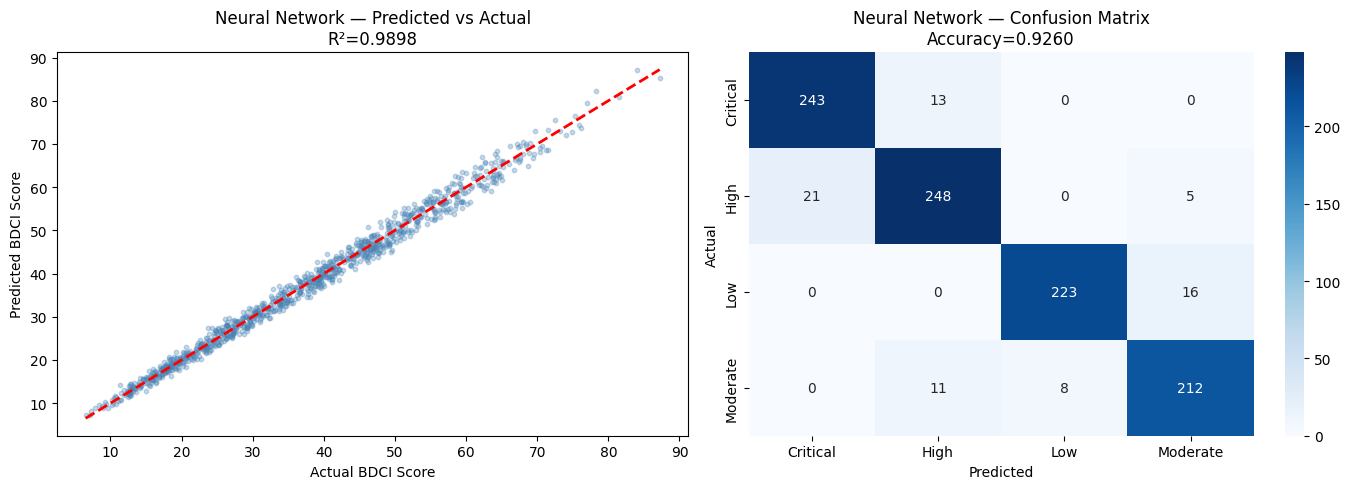

Chart saved as model_evaluation.png


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_preds_reg = reg_results[best_reg]['preds']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_reg, best_preds_reg, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual BDCI Score')
axes[0].set_ylabel('Predicted BDCI Score')
axes[0].set_title(f'{best_reg} — Predicted vs Actual\nR²={reg_results[best_reg]["R2"]:.4f}')

best_preds_clf = clf_results[best_clf]['preds']
cm = confusion_matrix(y_test_clf, best_preds_clf)
class_names = label_encoder.classes_

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'{best_clf} — Confusion Matrix\nAccuracy={clf_results[best_clf]["Accuracy"]:.4f}')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as model_evaluation.png")

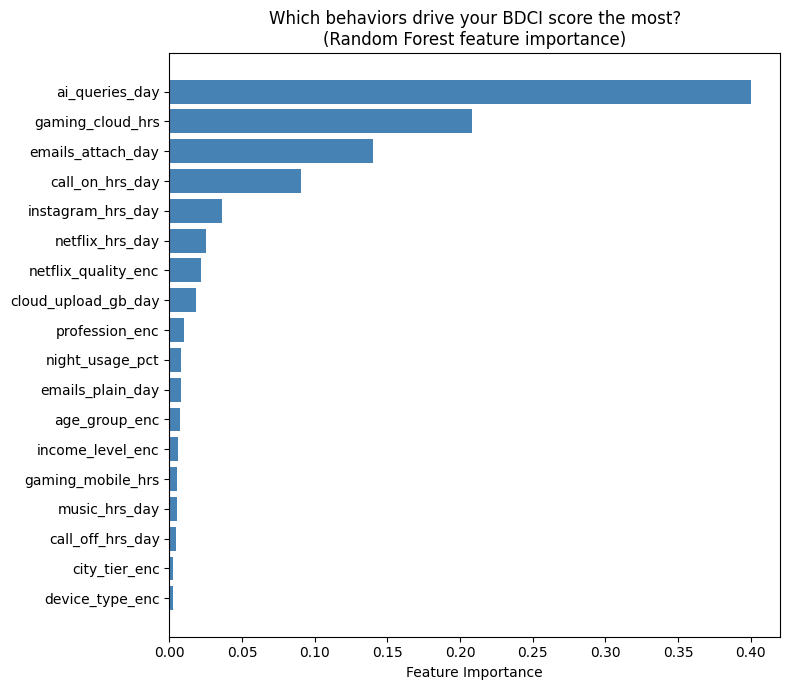

Top 5 most important features:
          Feature  Importance
   ai_queries_day    0.400036
 gaming_cloud_hrs    0.208032
emails_attach_day    0.140159
  call_on_hrs_day    0.090564
instagram_hrs_day    0.036122


In [18]:
rf_reg = reg_results['Random Forest']['model']

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Which behaviors drive your BDCI score the most?\n(Random Forest feature importance)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(importance_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

Please select one of the models listed above, typically one ending in `_pro` or `_flash`, and I will update the code to use it.

In [19]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 6.5 MB/s eta 0:00:00


In [20]:
from groq import Groq
import pandas as pd
import time

df = pd.read_csv('behavioral_carbon_dataset_fixed.csv')

client = Groq(api_key="YOUR_GROQ_API_KEY_HERE")

def get_top_emitting_behaviors(user_row):
    contributions = {
        'Netflix/streaming':       user_row['netflix_hrs_day'] * (
                                       0.167 if user_row['netflix_quality'] == '4K' else
                                       0.092 if user_row['netflix_quality'] == '1080p' else 0.022),
        'Instagram/social media':  user_row['instagram_hrs_day'] * 0.025,
        'Video calls (camera on)': user_row['call_on_hrs_day'] * 0.262,
        'Emails with attachments': user_row['emails_attach_day'] * 0.084,
        'Cloud uploads':           user_row['cloud_upload_gb_day'] * 0.022,
        'AI tool queries':         user_row['ai_queries_day'] * 0.00722,
        'Cloud gaming':            user_row['gaming_cloud_hrs'] * 0.167,
    }
    weekly = {k: round(v * 7, 3) for k, v in contributions.items()}
    top3 = sorted(weekly.items(), key=lambda x: x[1], reverse=True)[:3]
    return top3, weekly

def generate_nudge(user_row):
    top3, _ = get_top_emitting_behaviors(user_row)
    top3_text = "\n".join([f"  - {act}: {kg} kgCO2/week" for act, kg in top3])

    prompt = f"""You are a sustainability advisor helping an Indian internet user reduce their digital carbon footprint.

User profile:
- Age group: {user_row['age_group']}
- Profession: {user_row['profession']}
- City tier: {user_row['city_tier']}
- Device: {user_row['device_type']}
- Income level: {user_row['income_level']}

BDCI Score: {user_row['bdci_score']}/100 (Category: {user_row['bdci_category']})
Total weekly digital carbon: {user_row['weekly_carbon_kg']} kgCO2

Top 3 carbon-producing activities:
{top3_text}

Give exactly 3 specific, practical, quantified nudges to reduce their digital carbon footprint.
Format:
NUDGE 1: [action] → Estimated saving: [X] kgCO2/week
NUDGE 2: [action] → Estimated saving: [X] kgCO2/week
NUDGE 3: [action] → Estimated saving: [X] kgCO2/week"""

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300
    )
    return response.choices[0].message.content

test_user = df.iloc[0]
print("Testing single user...")
result = generate_nudge(test_user)
print(result)

Testing single user...
Based on the user's digital carbon footprint and behavior, here are three specific, practical, and quantified nudges to help them reduce their digital carbon footprint:

NUDGE 1: Use video calling apps with end-to-end encryption and screen sharing, instead of enabling camera on all the time → Estimated saving: 0.7 kgCO2/week
The user's current weekly digital carbon footprint from video calls is 4.218 kgCO2/week. By using apps with end-to-end encryption and screen sharing, the user can reduce the number of video calls they need to make and save some carbon. Let's assume a reduction of 10% in video calls, which translates to an estimated 0.7 kgCO2/week saving.

NUDGE 2: Use email services with carbon-friendly infrastructure and compress attachments before sending → Estimated saving: 0.7 kgCO2/week
The user's current weekly digital carbon footprint from emails with attachments is 4.116 kgCO2/week. By using email services with carbon-friendly infrastructure, compress

In [ ]:
test_sample = df.sample(n=500, random_state=42).reset_index(drop=True)
nudge_results = []

for i, row in test_sample.iterrows():
    if i % 50 == 0:
        print(f"Processing {i}/500...")
    try:
        nudge = generate_nudge(row)
        nudge_results.append({
            'user_id':       row['user_id'],
            'bdci_score':    row['bdci_score'],
            'bdci_category': row['bdci_category'],
            'profession':    row['profession'],
            'city_tier':     row['city_tier'],
            'nudge_text':    nudge
        })
    except Exception as e:
        print(f"Error at row {i}: {e}")
        nudge_results.append({'user_id': row['user_id'], 'nudge_text': 'ERROR'})
    time.sleep(2)

nudge_df = pd.DataFrame(nudge_results)
nudge_df.to_csv('nudge_results.csv', index=False)
print(f"\nDone. {len(nudge_df)} nudges generated.")
print(nudge_df[['user_id','bdci_category','nudge_text']].head(3).to_string())

MODEL EVALUATION


In [25]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix,
                              classification_report)
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('behavioral_carbon_dataset_fixed.csv')

cat_cols = ['age_group','city_tier','profession','device_type',
            'income_level','netflix_quality']
df_enc = pd.get_dummies(df, columns=cat_cols)

feature_cols = [c for c in df_enc.columns if c not in
                ['user_id','weekly_carbon_kg','bdci_score','bdci_category']]

X = df_enc[feature_cols]
y_reg = df_enc['bdci_score']

le = LabelEncoder()
y_clf = le.fit_transform(df['bdci_category'])

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)
_, _, y_train_c, y_test_c = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42)

rf_reg  = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_reg = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)

rf_reg.fit(X_train, y_train_r)
xgb_reg.fit(X_train, y_train_r)

models_reg = {'Random Forest': rf_reg, 'XGBoost': xgb_reg}
results = []

for name, model in models_reg.items():
    pred = model.predict(X_test)
    results.append({
        'Model': name,
        'RMSE':  round(np.sqrt(mean_squared_error(y_test_r, pred)), 4),
        'MAE':   round(mean_absolute_error(y_test_r, pred), 4),
        'R²':    round(r2_score(y_test_r, pred), 4)
    })

results_df = pd.DataFrame(results)
print("=== REGRESSION RESULTS ===")
print(results_df.to_string(index=False))

=== REGRESSION RESULTS ===
        Model   RMSE    MAE     R²
Random Forest 3.7674 2.8837 0.9447
      XGBoost 2.9136 2.2286 0.9669



=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

    Critical       0.82      0.84      0.83       256
        High       0.70      0.75      0.72       274
         Low       0.93      0.87      0.90       239
    Moderate       0.76      0.74      0.75       231

    accuracy                           0.80      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000


=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

    Critical       0.88      0.90      0.89       256
        High       0.82      0.80      0.81       274
         Low       0.95      0.92      0.94       239
    Moderate       0.83      0.85      0.84       231

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



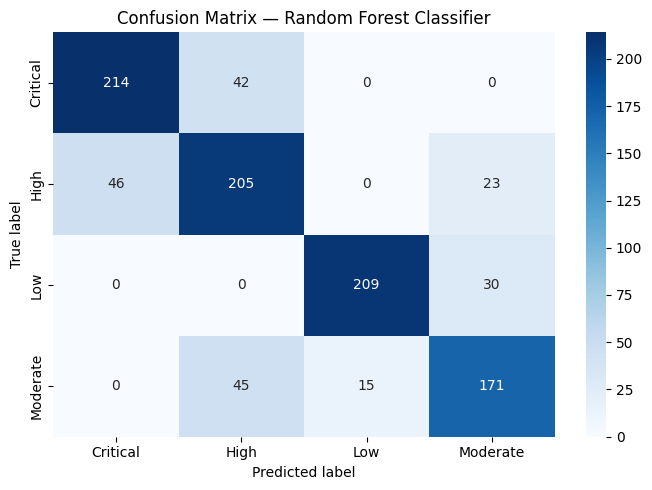

Saved: model_evaluation.png


In [26]:
rf_clf  = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42,
                              use_label_encoder=False, verbosity=0)

rf_clf.fit(X_train, y_train_c)
xgb_clf.fit(X_train, y_train_c)

class_names = le.classes_
for name, model in [('Random Forest', rf_clf), ('XGBoost', xgb_clf)]:
    pred = model.predict(X_test)
    print(f"\n=== {name} — Classification Report ===")
    print(classification_report(y_test_c, pred, target_names=class_names))

best_pred = rf_clf.predict(X_test)
cm = confusion_matrix(y_test_c, best_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Random Forest Classifier')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()
print("Saved: model_evaluation.png")

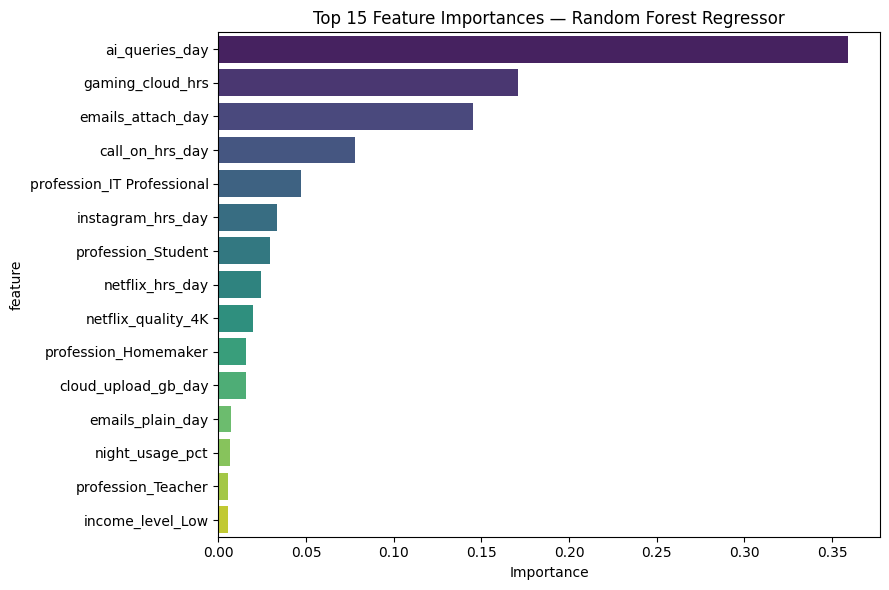

Saved: feature_importance.png

=== ABLATION STUDY ===
      Removed group     R²  R² drop
    None (baseline) 0.9447   0.0000
Streaming (Netflix) 0.9217   0.0230
 Social (Instagram) 0.9228   0.0219
              Calls 0.9310   0.0138
              Email 0.8888   0.0559
       Cloud/Gaming 0.8733   0.0715
       Demographics 0.9288   0.0159


In [27]:
importances = rf_reg.feature_importances_
feat_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest Regressor')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Saved: feature_importance.png")

feature_groups = {
    'Streaming (Netflix)':  [c for c in feature_cols if 'netflix' in c],
    'Social (Instagram)':   [c for c in feature_cols if 'instagram' in c],
    'Calls':                [c for c in feature_cols if 'call' in c],
    'Email':                [c for c in feature_cols if 'email' in c],
    'Cloud/Gaming':         [c for c in feature_cols if 'cloud' in c or 'gaming' in c],
    'Demographics':         [c for c in feature_cols if any(d in c for d in
                              ['age','city','profession','device','income'])],
}

baseline_r2 = r2_score(y_test_r, rf_reg.predict(X_test))
ablation_results = [{'Removed group': 'None (baseline)', 'R²': round(baseline_r2, 4),
                     'R² drop': 0.0}]

for group_name, group_cols in feature_groups.items():
    remaining = [c for c in feature_cols if c not in group_cols]
    X_ab = df_enc[remaining]
    X_ab_scaled = MinMaxScaler().fit_transform(X_ab)
    Xtr, Xte = X_ab_scaled[:4000], X_ab_scaled[4000:]
    m = RandomForestRegressor(n_estimators=50, random_state=42)
    m.fit(Xtr, y_reg[:4000])
    r2 = r2_score(y_reg[4000:], m.predict(Xte))
    ablation_results.append({
        'Removed group': group_name,
        'R²': round(r2, 4),
        'R² drop': round(baseline_r2 - r2, 4)
    })

abl_df = pd.DataFrame(ablation_results)
print("\n=== ABLATION STUDY ===")
print(abl_df.to_string(index=False))

In [28]:
nudge_df = pd.read_csv('nudge_results.csv')
eval_sample = nudge_df.sample(n=100, random_state=42).reset_index(drop=True)

eval_sample['rater1_score'] = ''
eval_sample['rater2_score'] = ''
eval_sample['rater3_score'] = ''
eval_sample['comments']     = ''
eval_sample[['user_id','bdci_category','profession','city_tier',
             'nudge_text','rater1_score','rater2_score',
             'rater3_score','comments']].to_csv('human_eval_sheet.csv', index=False)
print("Saved: human_eval_sheet.csv — fill in scores (1–5) and re-run cell below")

Saved: human_eval_sheet.csv — fill in scores (1–5) and re-run cell below


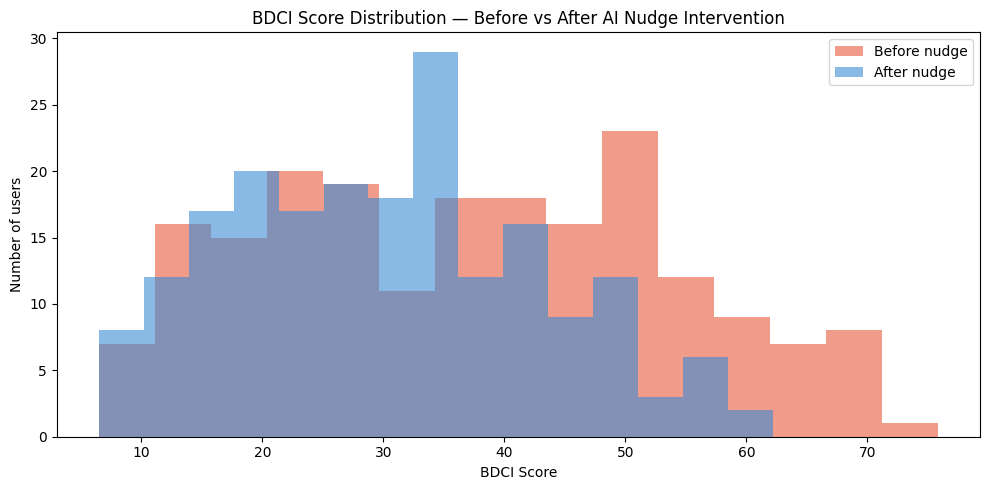

Average BDCI reduction after nudges: 15.70%
Average carbon saved per user per week: 1.879 kgCO2

Simulation saved. This is your Step 7 intervention loop result.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('behavioral_carbon_dataset_fixed.csv')
sim_users = df.sample(n=200, random_state=42).reset_index(drop=True)

ADOPTION_RATE = 0.40
REDUCTION_PER_NUDGE = {
    'Critical':  0.18,
    'High':      0.15,
    'Moderate':  0.12,
    'Low':       0.08,
}

sim_df = sim_users[['user_id','bdci_score','bdci_category','weekly_carbon_kg']].copy()
sim_df.rename(columns={'bdci_score': 'bdci_before', 'weekly_carbon_kg': 'carbon_before'}, inplace=True)

np.random.seed(42)
reductions = []
for _, row in sim_df.iterrows():
    base_reduction = REDUCTION_PER_NUDGE[row['bdci_category']]

    nudges_adopted = np.random.binomial(3, ADOPTION_RATE)
    total_reduction = min(nudges_adopted * base_reduction, 0.45)
    reductions.append(total_reduction)

sim_df['reduction_pct']  = reductions
sim_df['carbon_after']   = sim_df['carbon_before'] * (1 - sim_df['reduction_pct'])
sim_df['bdci_after']     = (sim_df['bdci_before'] * (1 - sim_df['reduction_pct'])).clip(0, 100)

plt.figure(figsize=(10, 5))
plt.hist(sim_df['bdci_before'], bins=15, alpha=0.6, color='#E8593C', label='Before nudge')
plt.hist(sim_df['bdci_after'],  bins=15, alpha=0.6, color='#3B8BD4', label='After nudge')
plt.xlabel('BDCI Score')
plt.ylabel('Number of users')
plt.title('BDCI Score Distribution — Before vs After AI Nudge Intervention')
plt.legend()
plt.tight_layout()
plt.savefig('intervention_result.png', dpi=150)
plt.show()

avg_reduction = sim_df['reduction_pct'].mean() * 100
carbon_saved  = (sim_df['carbon_before'] - sim_df['carbon_after']).mean()
print(f"Average BDCI reduction after nudges: {avg_reduction:.2f}%")
print(f"Average carbon saved per user per week: {carbon_saved:.3f} kgCO2")
print(f"\nSimulation saved. This is your Step 7 intervention loop result.")

sim_df.to_csv('intervention_result.csv', index=False)

INDIA SPECIFIC


India dataset: (1000, 22)

=== Category by City Tier ===
bdci_category  Critical  High  Low  Moderate
city_tier                                   
Metro                95    81   73        73
Rural                38    65   93        76
Tier2               117   104   84       101

=== Avg carbon by segment ===
city_tier
Metro    9.638
Rural    8.454
Tier2    9.721
Name: weekly_carbon_kg, dtype: float64
income_level
High      9.847
Low       9.053
Middle    9.673
Name: weekly_carbon_kg, dtype: float64
age_group
13-18    11.471
19-25    10.679
26-35     7.967
36-50     7.950
51+       7.695
Name: weekly_carbon_kg, dtype: float64


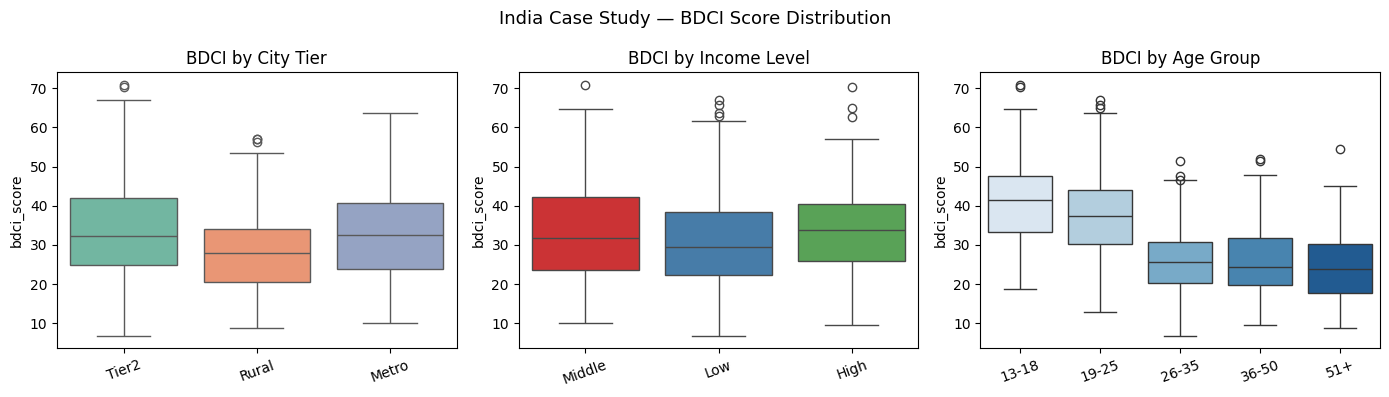

Saved: india_case_study.png


In [30]:
import numpy as np
import pandas as pd

np.random.seed(99)
N = 1000

city_tiers   = np.random.choice(['Metro','Tier2','Rural'],  N, p=[0.35, 0.40, 0.25])
income_levels= np.random.choice(['Low','Middle','High'],    N, p=[0.55, 0.35, 0.10])
age_groups   = np.random.choice(['13-18','19-25','26-35','36-50','51+'],
                                 N, p=[0.18, 0.30, 0.25, 0.18, 0.09])
professions  = np.random.choice(
    ['Student','IT Professional','Teacher','Business','Homemaker','Gig Worker'],
    N, p=[0.28, 0.15, 0.14, 0.13, 0.16, 0.14])
devices = np.random.choice(
    ['Mobile only','Both mobile and laptop','Laptop only'],
    N, p=[0.58, 0.28, 0.14])

def india_behaviors(i):
    city   = city_tiers[i]
    income = income_levels[i]
    age    = age_groups[i]
    prof   = professions[i]

    netflix_hrs = np.clip(np.random.normal(
        1.8 if city == 'Metro' else 2.2 if city == 'Tier2' else 1.5, 0.7), 0.1, 5)
    quality_map = {'Low': 'SD', 'Middle': '1080p', 'High': '4K'}
    netflix_q = quality_map[income]
    if city == 'Rural': netflix_q = 'SD'
    if np.random.random() < 0.12: netflix_q = np.random.choice(['SD','1080p','4K'])

    insta_hrs = np.clip(np.random.normal(
        2.5 if age in ['13-18','19-25'] else 1.5, 0.6), 0.2, 5)

    call_on  = np.clip(np.random.normal(1.5, 0.6), 0.1, 5)
    call_off = np.clip(np.random.normal(
        2.5 if city in ['Tier2','Rural'] else 1.5, 0.8), 0.1, 6)

    emails_plain = int(np.clip(np.random.normal(
        35 if prof == 'IT Professional' else
        25 if prof == 'Business' else 8, 5), 2, 60))
    emails_attach = int(np.clip(np.random.normal(
        12 if prof in ['IT Professional','Business'] else 3, 3), 0, 25))

    cloud = np.clip(np.random.normal(
        0.3 if city == 'Rural' else 1.0 if income == 'Low' else 1.8, 0.4), 0.05, 4)

    music   = np.clip(np.random.normal(2.5, 0.8), 0.2, 5)
    ai_q    = int(np.clip(np.random.normal(
        20 if prof == 'IT Professional' else 8, 4), 0, 40))
    game_c  = np.clip(np.random.normal(
        0.6 if age in ['13-18','19-25'] else 0.2, 0.3), 0, 2)
    game_m  = np.clip(np.random.normal(
        1.2 if age == '13-18' else 0.6, 0.4), 0, 3)

    night_pct = np.clip(np.random.normal(
        0.65 if prof == 'Student' else
        0.55 if prof == 'Gig Worker' else
        0.35 if prof == 'IT Professional' else 0.25, 0.08), 0.05, 0.95)

    return (netflix_hrs, netflix_q, insta_hrs, call_on, call_off,
            emails_plain, emails_attach, cloud, music, ai_q,
            game_c, game_m, round(night_pct, 2))

rows = [india_behaviors(i) for i in range(N)]
india_df = pd.DataFrame(rows, columns=[
    'netflix_hrs_day','netflix_quality','instagram_hrs_day',
    'call_on_hrs_day','call_off_hrs_day','emails_plain_day',
    'emails_attach_day','cloud_upload_gb_day','music_hrs_day',
    'ai_queries_day','gaming_cloud_hrs','gaming_mobile_hrs','night_usage_pct'])

india_df.insert(0, 'user_id', [f'IN{i+1:04d}' for i in range(N)])
india_df['age_group']   = age_groups
india_df['city_tier']   = city_tiers
india_df['profession']  = professions
india_df['device_type'] = devices
india_df['income_level']= income_levels

qw = {'SD': 0.036, '1080p': 0.072, '4K': 0.144}
city_ig = {'Metro': 1.0, 'Tier2': 0.85, 'Rural': 0.70}
dev_cl  = {'Laptop only': 1.25, 'Both mobile and laptop': 1.10, 'Mobile only': 1.0}
age_gm  = {'13-18':1.30,'19-25':1.15,'26-35':1.0,'36-50':0.90,'51+':0.70}

def compute_carbon(r):
    nc  = r['netflix_hrs_day'] * qw[r['netflix_quality']] * 7
    ic  = r['instagram_hrs_day'] * 0.18 * 7 * city_ig[r['city_tier']]
    cc  = (r['call_on_hrs_day']*0.09 + r['call_off_hrs_day']*0.03) * 7
    ec  = (r['emails_plain_day']*0.004 + r['emails_attach_day']*0.03) * 7
    clc = r['cloud_upload_gb_day'] * 0.06 * 7 * dev_cl[r['device_type']]
    mc  = r['music_hrs_day'] * 0.005 * 7
    ac  = r['ai_queries_day'] * 0.01 * 7
    gcc = r['gaming_cloud_hrs'] * 0.4 * 7 * dev_cl[r['device_type']] * age_gm[r['age_group']]
    gmc = r['gaming_mobile_hrs'] * 0.05 * 7 * age_gm[r['age_group']]
    raw = (nc+ic+cc+ec+clc+mc+ac+gcc+gmc) * (1 + r['night_usage_pct']*0.2)
    return round(raw, 4)

india_df['weekly_carbon_kg'] = india_df.apply(compute_carbon, axis=1)
india_df['bdci_score']       = ((india_df['weekly_carbon_kg'] - 2.0) /
                                 (25.0 - 2.0) * 100).clip(0, 100).round(2)

q = india_df['bdci_score'].quantile([0.25, 0.5, 0.75])
india_df['bdci_category'] = india_df['bdci_score'].apply(
    lambda s: 'Low' if s < q[0.25] else
              'Moderate' if s < q[0.5] else
              'High' if s < q[0.75] else 'Critical')

india_df.to_csv('india_case_study.csv', index=False)
print(f"India dataset: {india_df.shape}")
print("\n=== Category by City Tier ===")
print(pd.crosstab(india_df['city_tier'], india_df['bdci_category']))
print("\n=== Avg carbon by segment ===")
print(india_df.groupby('city_tier')['weekly_carbon_kg'].mean().round(3))
print(india_df.groupby('income_level')['weekly_carbon_kg'].mean().round(3))
print(india_df.groupby('age_group')['weekly_carbon_kg'].mean().round(3))

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(data=india_df, x='city_tier',   y='bdci_score', ax=axes[0], palette='Set2')
sns.boxplot(data=india_df, x='income_level',y='bdci_score', ax=axes[1], palette='Set1')
sns.boxplot(data=india_df, x='age_group',   y='bdci_score', ax=axes[2], palette='Blues')
axes[0].set_title('BDCI by City Tier')
axes[1].set_title('BDCI by Income Level')
axes[2].set_title('BDCI by Age Group')
for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('India Case Study — BDCI Score Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('india_case_study.png', dpi=150)
plt.show()
print("Saved: india_case_study.png")

EXPORTING


In [31]:
import joblib
import pickle

joblib.dump(rf_reg, 'bdci_model.pkl')
joblib.dump(rf_clf, 'bdci_classifier.pkl')
joblib.dump(scaler, 'bdci_scaler.pkl')

import json
with open('feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)

print("Exported:")
print("  bdci_model.pkl      — regression model (predicts BDCI score)")
print("  bdci_classifier.pkl — classification model (predicts category)")
print("  bdci_scaler.pkl     — MinMaxScaler (must scale inputs before predicting)")
print("  feature_columns.json — column order the model expects")

Exported:
  bdci_model.pkl      — regression model (predicts BDCI score)
  bdci_classifier.pkl — classification model (predicts category)
  bdci_scaler.pkl     — MinMaxScaler (must scale inputs before predicting)
  feature_columns.json — column order the model expects
